<a href="https://colab.research.google.com/github/monssef12/DSP-with-python/blob/main/DSP_Basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Digital filter**

## Finite Impulse Response (FIR) Filter

Filtering always relies on assumptions about the signal you want to recover.

$$
y[n] = \sum_{k=0}^{M-1} h[k]x[n-k]
$$

Explicitly:
$$
\begin{aligned}
y[n] = & \, h[0]x[n] \\
& + h[1]x[n-1] \\
& + h[2]x[n-2] \\
& + \dots \\
& + h[M-1]x[n-(M-1)]
\end{aligned}
$$

Example with four taps ($M=4$):
$$
\begin{aligned}
y[n] = & \, h[0]x[n] \\
& + h[1]x[n-1] \\
& + h[2]x[n-2] \\
& + h[3]x[n-3]
\end{aligned}
$$

### Parameter Definitions
* **$y[n]$**: Output signal at time index $n$
* **$x[n]$**: Input signal
* **$h[k]$**: FIR filter coefficient (tap) at index $k$
* **$M$**: Number of filter taps (filter length)
* **$k$**: Summation index (runs over filter taps)

---

### Key Characteristics
* **Frequency Selection:** An FIR filter is used to filter unwanted frequency signals from the sampled signal or extract parts of a signal, just by specifying the coefficients used to multiply them by the input signal.
* **Non-Recursive Architecture:** Finite Impulse Response relies solely on current and past input samples.
* **Linear Phase:** FIR filters can easily be designed to have an exact linear phase response. This means they delay all frequency components equally, preserving the exact shape of the waveform without phase distortion.


In [ ]:
def fir_filter(input_signal, coefficients): #simple implementation of the FIR filter
  output_signal = [0] * len(input_signal)
  for i in range(len(input_signal)):
    for j in range(len(coefficients)):
      if i-j >= 0:
        output_signal[i] += coefficients[j] * input_signal[i-j]
  return output_signal

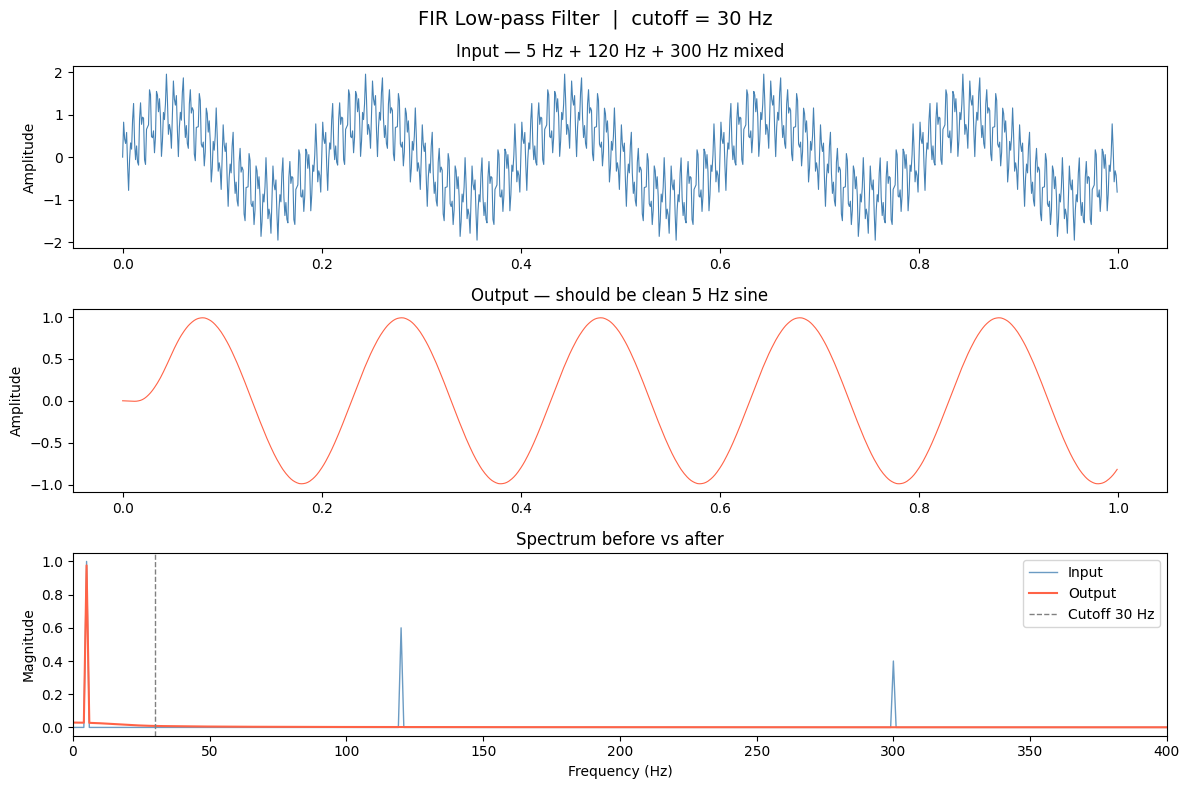

In [ ]:
import numpy as np
from scipy.signal import firwin
import matplotlib.pyplot as plt

# 1000 Hz ADC, must match the real hardware otherwise everything shift
fs = 1000
N  = 1000        # 1 second of data
t  = np.linspace(0, N/fs, N, endpoint=False)

# 5 Hz is our actual signal, the rest is just noise (motor, EMI, whatever)
f_low  = 5
f_mid  = 120
f_high = 300

# what the ADC sees in real world — useful signal buried in noise
signal = (1.0 * np.sin(2 * np.pi * f_low  * t) +
          0.6 * np.sin(2 * np.pi * f_mid  * t) +
          0.4 * np.sin(2 * np.pi * f_high * t))

# 30 Hz gives good margin between what we keep (5Hz) and what we kill (120Hz+)
cutoff = 30

# 61 is good tradeoff, odd number to avoid half-sample delay issues
# tune this down if MCU cycles are tight
num_taps = 61

# firwin compute the coefficients for us, hamming is safe default choice
coeffs = firwin(num_taps, cutoff, fs=fs, window='hamming')

# same math a DSP library do, just not optimized
filtered = fir_filter(list(signal), list(coeffs))

fig, axes = plt.subplots(3, 1, figsize=(12, 8))
fig.suptitle('FIR Low-pass Filter  |  cutoff = 30 Hz', fontsize=14)

axes[0].plot(t, signal, color='steelblue', linewidth=0.8)
axes[0].set_title('Input — 5 Hz + 120 Hz + 300 Hz mixed')
axes[0].set_ylabel('Amplitude')

# first ~30 samples will have transient, thats normal, filter need time to fill up
axes[1].plot(t, filtered, color='tomato', linewidth=0.8)
axes[1].set_title('Output — should be clean 5 Hz sine')
axes[1].set_ylabel('Amplitude')

# rfft give us positive freqs only, enough to see the spikes
freqs  = np.fft.rfftfreq(N, 1/fs)
sp_in  = np.abs(np.fft.rfft(signal))   / (N/2)
sp_out = np.abs(np.fft.rfft(filtered)) / (N/2)

# blue has 3 spikes, red should have only one at 5 Hz
axes[2].plot(freqs, sp_in,  color='steelblue', linewidth=1,   label='Input',  alpha=0.8)
axes[2].plot(freqs, sp_out, color='tomato',    linewidth=1.5, label='Output')
axes[2].axvline(cutoff, color='gray', linestyle='--', linewidth=1, label=f'Cutoff {cutoff} Hz')
axes[2].set_xlim(0, 400)
axes[2].set_title('Spectrum before vs after')
axes[2].set_xlabel('Frequency (Hz)')
axes[2].set_ylabel('Magnitude')
axes[2].legend()

plt.tight_layout()
plt.savefig('fir_output.png', dpi=150)
plt.show()

## Infinite Impulse Response (IIR) Filter


$$
y[n] = \sum_{k=0}^{M-1} b[k]x[n-k] - \sum_{k=1}^{N} a[k]y[n-k]
$$

Explicitly:
$$
\begin{aligned}
y[n] = & \, b[0]x[n] \\
& + b[1]x[n-1] \\
& + b[2]x[n-2] \\
& - a[1]y[n-1] \\
& - a[2]y[n-2] \\
& - \dots
\end{aligned}
$$

Example with M=3, N=2:
$$
\begin{aligned}
y[n] = & \, b[0]x[n] \\
& + b[1]x[n-1] \\
& + b[2]x[n-2] \\
& - a[1]y[n-1] \\
& - a[2]y[n-2]
\end{aligned}
$$

### Parameter Definitions
* **$y[n]$**: output sample we're computing right now
* **$x[n]$**: current input sample
* **$b[k]$**: feedforward coefficients — act on past inputs, same idea as FIR taps
* **$a[k]$**: feedback coefficients — act on past *outputs*, this is what makes IIR different
* **$M$**: how many input samples we look back at
* **$N$**: how many output samples we feed back

---

### Key Characteristics
* **Recursive by nature:** the output depends on previous outputs — the filter feeds itself. thats where "infinite impulse response" comes from, a single impulse can echo through the feedback loop forever in theory.
* **Much more efficient than FIR:** sharp frequency response with just 4–6 coefficients where FIR would need hundreds of taps. thats why IIR is common in embedded and real-time DSP.
* **Non-linear phase:** feedback causes different frequencies to be delayed by different amounts, waveform shape wont be perfectly preserved. for ECG or audio this can matter, for simple frequency rejection usually doesnt.
* **Can be unstable:** wrong feedback coefficients and the output grows unbounded and blows up. FIR can never do this — with IIR you always need to check stability, especially in fixed-point on MCU.

In [ ]:
def IIR_filter(input_signal, Present_coefficients, Past_Coefficients):  #simple implementation of the FIR filter
  output_signal = [0] * len(input_signal)
  for i in range(len(input_signal)):
    for j in range(len(Present_coefficients)):
      if i-j >= 0:
        output_signal[i] += Present_coefficients[j] * input_signal[i-j]
      else:
        break

    for k in range(1, len(Past_Coefficients)+1):
      if i-k >= 0 :
        output_signal[i] -= Past_Coefficients[k-1] * output_signal[i-k]
      else:
        break;
  return output_signal


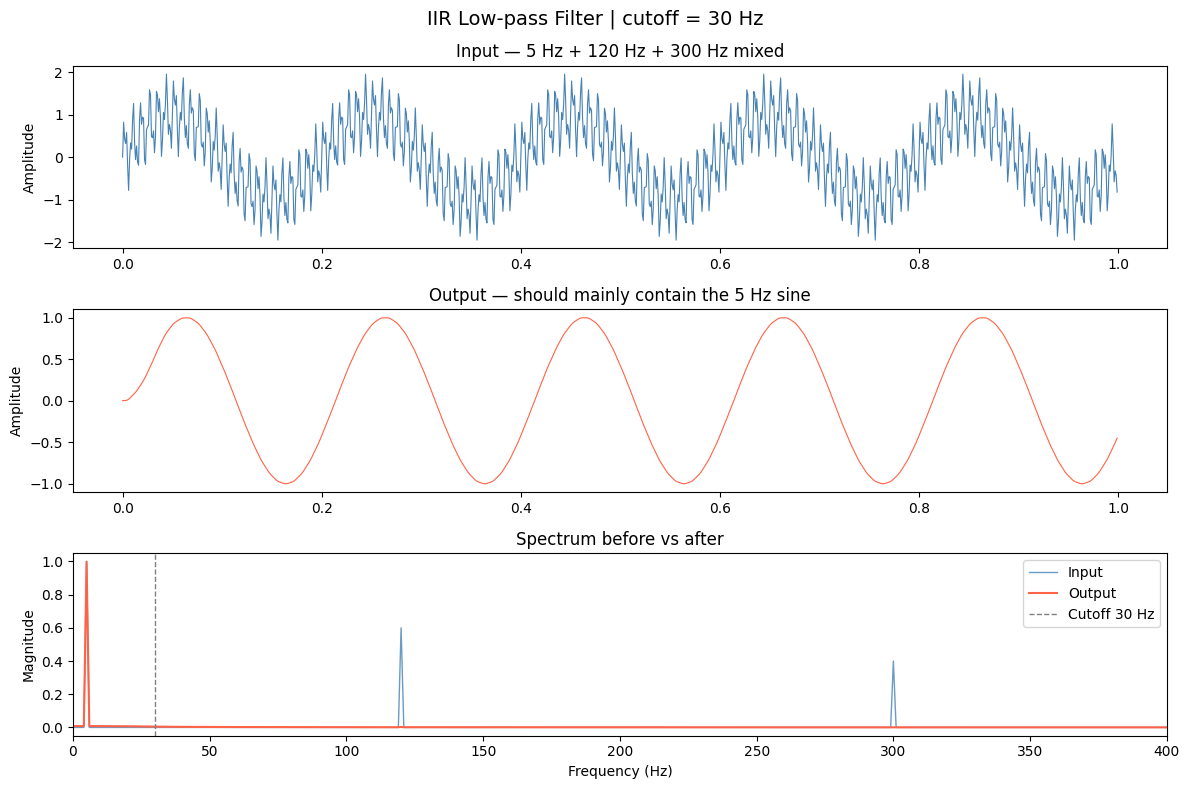

In [ ]:
import numpy as np
from scipy.signal import butter
import matplotlib.pyplot as plt

# 1000 Hz ADC
fs = 1000
N  = 1000
t  = np.linspace(0, N/fs, N, endpoint=False)

# actual signal + unwanted frequencies
f_low  = 5
f_mid  = 120
f_high = 300

signal = (1.0 * np.sin(2 * np.pi * f_low  * t) +
          0.6 * np.sin(2 * np.pi * f_mid  * t) +
          0.4 * np.sin(2 * np.pi * f_high * t))

# 30 Hz cutoff
cutoff = 30

# 4th-order Butterworth IIR low-pass
b, a = butter(4, cutoff, fs=fs)

# Your implementation expects:
# y[n] = Σ b[k]x[n-k] - Σ a[k]y[n-k]
#
# where Past_Coefficients = [a1, a2, ...]
Present_coefficients = list(b)
Past_Coefficients = list(a[1:])

filtered = IIR_filter(list(signal),
                      Present_coefficients,
                      Past_Coefficients)

fig, axes = plt.subplots(3, 1, figsize=(12, 8))
fig.suptitle('IIR Low-pass Filter | cutoff = 30 Hz', fontsize=14)

axes[0].plot(t, signal, color='steelblue', linewidth=0.8)
axes[0].set_title('Input — 5 Hz + 120 Hz + 300 Hz mixed')
axes[0].set_ylabel('Amplitude')

# unlike FIR, IIR transient theoretically never fully disappears
axes[1].plot(t, filtered, color='tomato', linewidth=0.8)
axes[1].set_title('Output — should mainly contain the 5 Hz sine')
axes[1].set_ylabel('Amplitude')

freqs  = np.fft.rfftfreq(N, 1/fs)
sp_in  = np.abs(np.fft.rfft(signal))   / (N/2)
sp_out = np.abs(np.fft.rfft(filtered)) / (N/2)

axes[2].plot(freqs, sp_in,
             color='steelblue',
             linewidth=1,
             label='Input',
             alpha=0.8)

axes[2].plot(freqs, sp_out,
             color='tomato',
             linewidth=1.5,
             label='Output')

axes[2].axvline(cutoff,
                color='gray',
                linestyle='--',
                linewidth=1,
                label=f'Cutoff {cutoff} Hz')

axes[2].set_xlim(0, 400)
axes[2].set_title('Spectrum before vs after')
axes[2].set_xlabel('Frequency (Hz)')
axes[2].set_ylabel('Magnitude')
axes[2].legend()

plt.tight_layout()
plt.savefig('iir_output.png', dpi=150)
plt.show()

## Fourier Tranform


Fast Fourier transform is a mathematical operation that extract frequencies from a signal.
like when we hear music, we hear one sound, one signal, one value at a time, but it might actually contain different frequencies mixed together. The microphone gives you One waveform, then FT basicaly tells you this waveform is actually made from these frequencies and how much each one contribute in that signal via amplituted coefficients.

$$
X(f)=\int_{-\infty}^{+\infty}x(t)e^{-j2\pi ft}\,dt
$$

where:

- $x(t)$ : Time-domain signal.
- $X(f)$ : Frequency-domain representation of the signal.
- $f$ : Frequency (Hz).
- $t$ : Time (seconds).
- $j=\sqrt{-1}$ : Imaginary unit.
- $e^{-j2\pi ft}$ : Complex exponential used to analyze the contribution of frequency $f$.

## Discrete Fourier Transform (DFT)

Unlike the Continuous Fourier Transform, the DFT operates on **N discrete samples** collected by an ADC or any digital acquisition system.

The DFT transforms these **N time-domain samples** into **N complex frequency coefficients**. Each coefficient, denoted by $X[k]$, corresponds to a **frequency bin**, which represents one discrete frequency analyzed by the DFT. The magnitude of $X[k]$ indicates how strongly that frequency contributes to the original signal, while its phase indicates the angular offset of that frequency component.

### DFT Equation

$$
X[k]=\sum_{n=0}^{N-1}x[n]\,e^{-j\frac{2\pi kn}{N}}
$$

where

- $x[n]$ : Input signal (time-domain samples)
- $X[k]$ : Complex coefficient corresponding to the $k^{th}$ frequency bin
- $N$ : Total number of input samples
- $n$ : Time-domain sample index ($0 \le n < N$)
- $k$ : Frequency-bin index ($0 \le k < N$)
- $j=\sqrt{-1}$ : Imaginary unit

## Frequency Bin

A **frequency bin** is one of the discrete frequencies evaluated by the DFT. Since only **N samples** are available, the DFT computes the spectrum at **N equally spaced frequency locations** instead of every possible frequency.

The frequency corresponding to bin $k$ is

$$
f_k=\frac{kF_s}{N}
$$

where

- $f_k$ : Frequency represented by bin $k$ (Hz)
- $F_s$ : Sampling frequency (Hz)
- $N$ : Number of samples
- $k$ : Frequency-bin index

The spacing between adjacent bins, called the **frequency resolution**, is

$$
\Delta f=\frac{F_s}{N}
$$


In [ ]:
import numpy as np

def dft(x):
    N = len(x)
    X = np.zeros(N, dtype=complex)
    for k in range(N):
        summation = 0
        for n in range(N):
            angle = -2j * np.pi * k * n / N
            summation += x[n] * np.exp(angle)
        X[k] = summation
    return X

Example

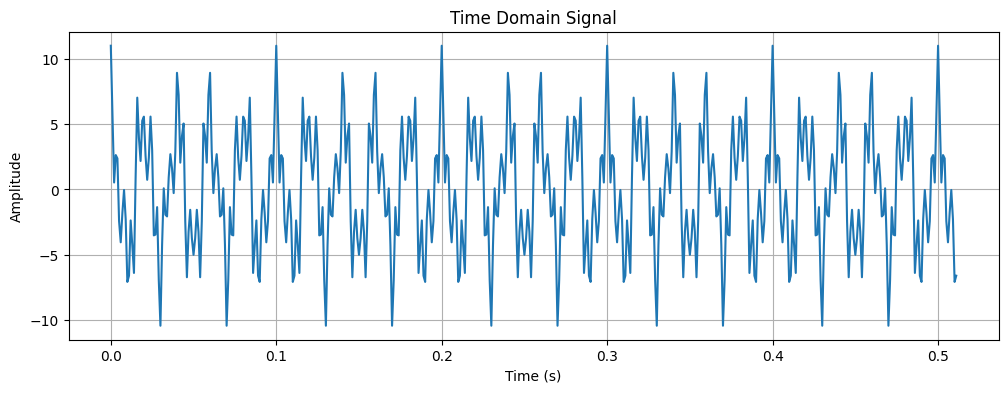

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Sampling parameters

Fs = 1000          # Sampling frequency in Hz
N = 512            # Number of samples

t = np.arange(N) / Fs

#Signal
x = (
    5*np.cos(2*np.pi*50*t) +
    2*np.cos(2*np.pi*120*t) +
    3*np.cos(2*np.pi*250*t) +
    1*np.cos(2*np.pi*320*t)
)


# plot
plt.figure(figsize=(12,4))
plt.plot(t, x)
plt.title("Time Domain Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

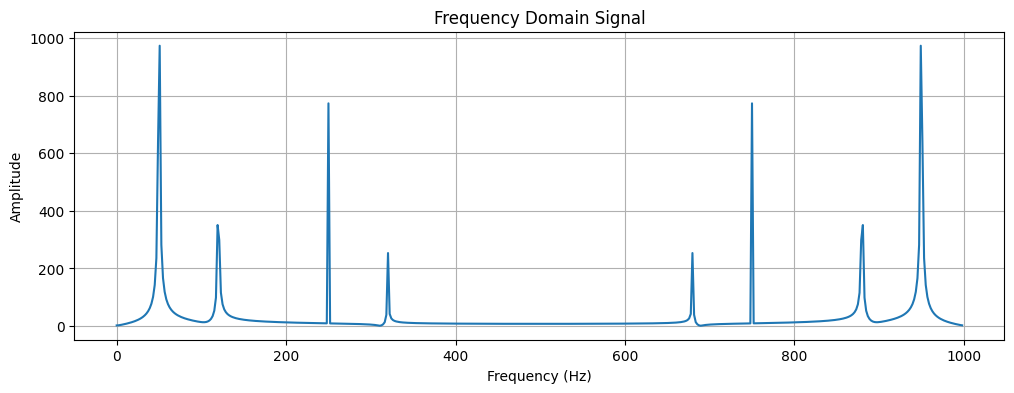

In [ ]:
X = dft(x)
freq = np.arange(N) * Fs / N

plt.figure(figsize=(12,4))
plt.plot(freq, np.abs(X))
plt.title("Frequency Domain Signal")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

## Fast Fourier transform

### Fast Fourier Transform (FFT)

The **Fast Fourier Transform (FFT)** is an efficient algorithm used to compute the **Discrete Fourier Transform (DFT)**. Unlike the DFT, which directly evaluates the DFT equation for every frequency bin, the FFT reorganizes the computation to eliminate redundant calculations. This significantly reduces the computational complexity from **$O(N^2)$** to **$O(N\log_2N)$**, making real-time frequency analysis practical for embedded systems and digital signal processing applications.

Importantly, the FFT does **not** produce a different result than the DFT. It computes the **same set of N complex frequency coefficients**, preserving the magnitude and phase information of every frequency bin while requiring far fewer arithmetic operations.

> **Note:** The FFT is **not a different mathematical transform**. It is simply a computationally efficient algorithm for evaluating the DFT. Therefore, every property and interpretation of the DFT also applies to the FFT.

In [5]:
def FFT(x):

 #   input signal should have a length of
 #   power of 2.

    N = len(x)

    if N == 1:
        return x
    else:
        X_even = FFT(x[::2])
        X_odd = FFT(x[1::2])
        factor = np.exp(-2j*np.pi*np.arange(N)/ N)

        X = np.concatenate(
            [X_even+factor[:int(N/2)]*X_odd,
             X_even+factor[int(N/2):]*X_odd])
        return X

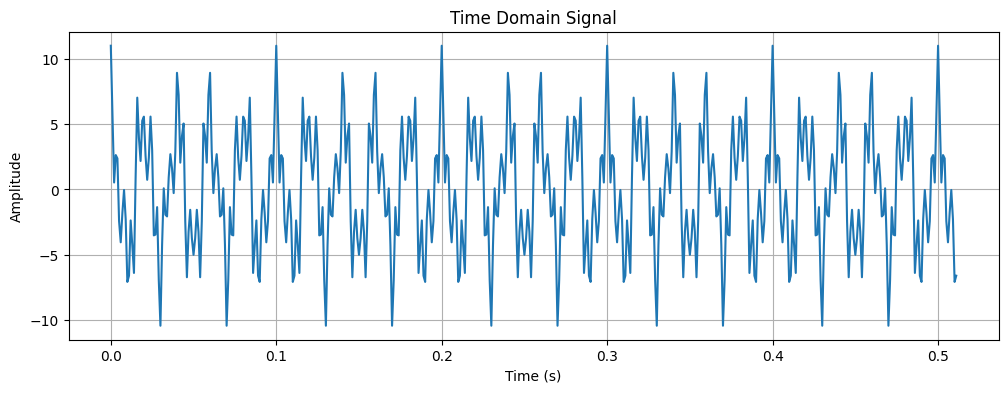

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Sampling parameters

Fs = 1000          # Sampling frequency in Hz
N = 512            # Number of samples

t = np.arange(N) / Fs

#Signal
x = (
    5*np.cos(2*np.pi*50*t) +
    2*np.cos(2*np.pi*120*t) +
    3*np.cos(2*np.pi*250*t) +
    1*np.cos(2*np.pi*320*t)
)


# plot
plt.figure(figsize=(12,4))
plt.plot(t, x)
plt.title("Time Domain Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

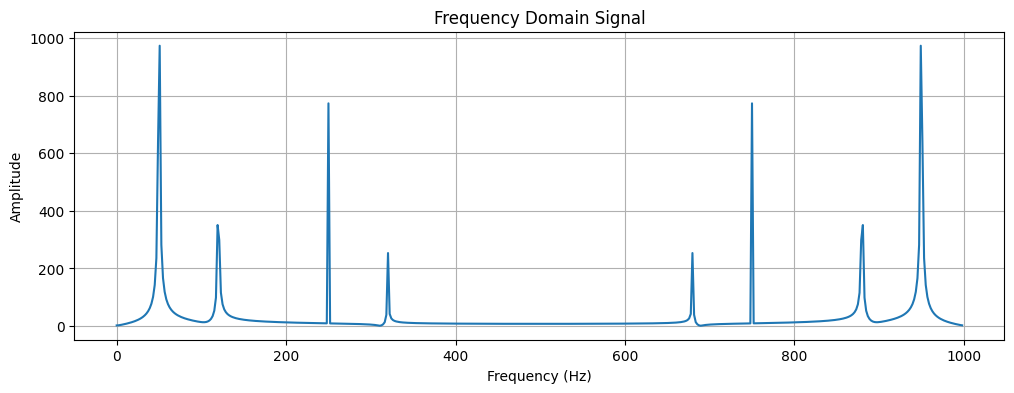

In [7]:
X = FFT(x)
freq = np.arange(N) * Fs / N

plt.figure(figsize=(12,4))
plt.plot(freq, np.abs(X))
plt.title("Frequency Domain Signal")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()